In [1]:
!pip install opencv-python -q

In [2]:
import   cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image


### Question 1 Counting objects

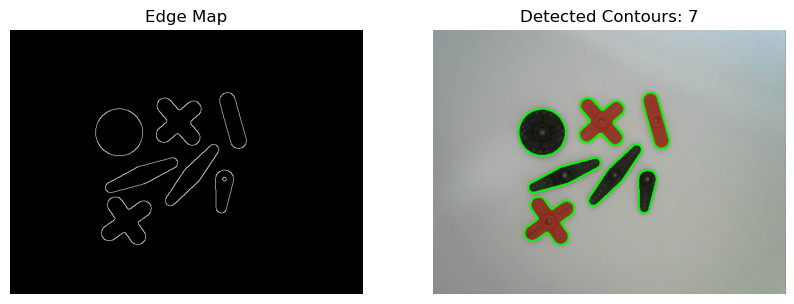

7

In [3]:
## Sample images  in Data directory
def count_objects(image_path):
    # Load the image using opencv
    img = cv2.imread(image_path)
    # Convert the image to grayscale for easy manipulation
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Apply GaussianBlur to reduce noise and help contour detection
    blurred =cv2.GaussianBlur(gray, (5,5),0)
    # Use Canny edge detection we could also use sobel
    edges = cv2.Canny(blurred, 30, 150)
    # Find contours in the edges, this can help to detect the edges 
    contours, _ = cv2.findContours(edges, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    # Count the number of objects which should just be the number of contours you have
    count = len(contours)
    # return the number of objects

    # Visualizing the result (Optional but recommended for debugging)
    # Draw contours on a copy of the original image
    output_img = img.copy()
    cv2.drawContours(output_img, contours, -1, (0, 255, 0), 2) # -1 draws all contours, Green color, Thickness 2

    # Display using matplotlib (handles BGR to RGB conversion for display)
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.title("Edge Map")
    plt.imshow(edges, cmap='gray')
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.title(f"Detected Contours: {count}")
    plt.imshow(cv2.cvtColor(output_img, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.show()
    
    return count


count_objects("q1_data/1a.png")


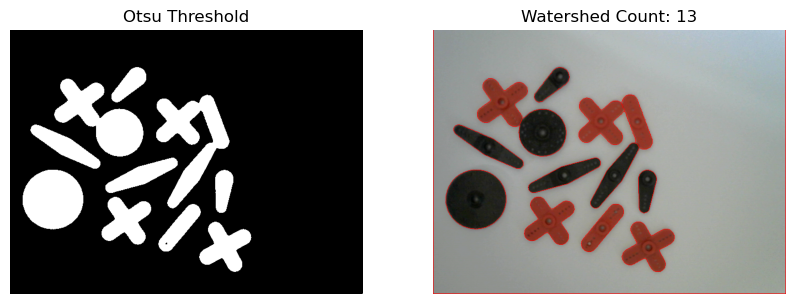

np.int32(13)

In [4]:
def count_touching_objects(image_path):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not load image at {image_path}")
        return 0
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    
    # Reduced iterations from 2 to 1 to preserve thin objects
    kernel = np.ones((3,3), np.uint8)
    opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel, iterations=1)
    
    sure_bg = cv2.dilate(opening, kernel, iterations=3)
    
    dist_transform = cv2.distanceTransform(opening, cv2.DIST_L2, 5)
    # 0.15 is between 0.1 (gave 10) and 0.5 (gave 2)
    _, sure_fg = cv2.threshold(dist_transform, 0.15 * dist_transform.max(), 255, 0)
    
    sure_fg = np.uint8(sure_fg)
    unknown = cv2.subtract(sure_bg, sure_fg)
    
    _, markers = cv2.connectedComponents(sure_fg)
    markers = markers + 1
    markers[unknown == 255] = 0
    
    markers = cv2.watershed(img, markers)
    img[markers == -1] = [0, 0, 255]
    
    count = markers.max() - 1
    
    plt.figure(figsize=(10, 5))
    plt.subplot(1, 2, 1)
    plt.imshow(thresh, cmap='gray')
    plt.title("Otsu Threshold")
    plt.axis('off')
    
    plt.subplot(1, 2, 2)
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"Watershed Count: {count}")
    plt.axis('off')
    plt.show()
    return count

count_touching_objects("q1_data/1b.png")

## **Real-World Experiment**

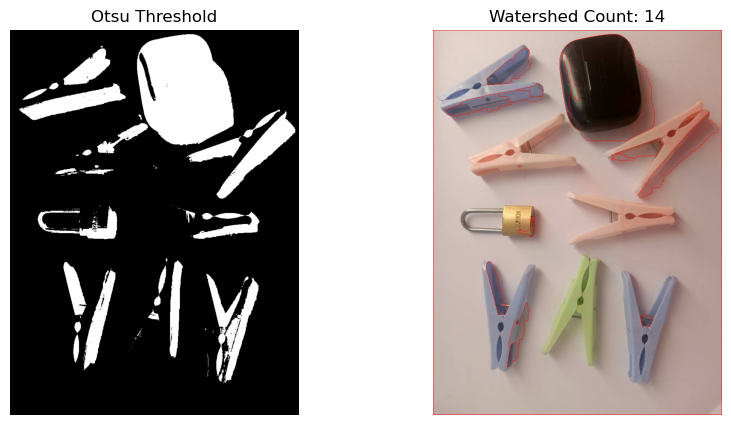

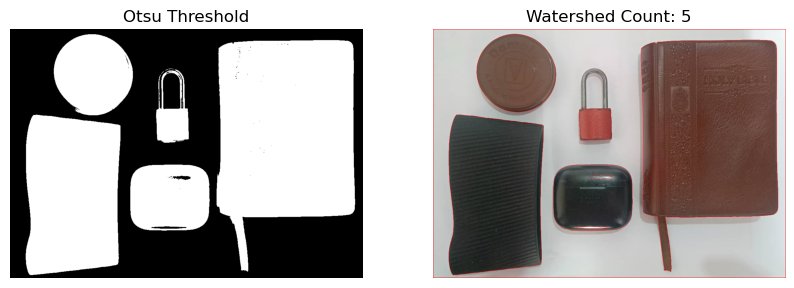

np.int32(5)

In [5]:
count_touching_objects("q1_data/real_world.jpeg")
count_touching_objects("q1_data/stuffs.jpeg")

## **BONUS**

In [6]:
import cv2
import numpy as np
import os

def process_video(input_video_path, output_video_path):
    """
    Process video frame-by-frame using the naive object counting pipeline.
    Uses: Grayscale -> Blur -> Canny -> Contours (same as Q1).
    """
    cap = cv2.VideoCapture(input_video_path)
    
    if not cap.isOpened():
        print(f"Error: Could not open video file {input_video_path}")
        return

    width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps    = cap.get(cv2.CAP_PROP_FPS)

    fourcc = cv2.VideoWriter_fourcc(*'mp4v') 
    out = cv2.VideoWriter(output_video_path, fourcc, fps, (width, height))

    frame_count = 0
    
    print(f"Processing video: {input_video_path}")
    print(f"Resolution: {width}x{height}, FPS: {fps}")
    
    # Scale min_area relative to frame size
    # For 1920x1080, total pixels = ~2M. A real object should be at least 0.1% of the frame.
    total_pixels = width * height
    min_area = int(total_pixels * 0.005)  # 0.5% of frame = ~10000 pixels for 1080p
    print(f"Min contour area filter: {min_area} pixels")
    
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret:
            break
            
        frame_count += 1
        
        # --- Object Counting Pipeline (Same as Q1) ---
        
        # 1. Grayscale
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        
        # 2. Gaussian Blur
        blurred = cv2.GaussianBlur(gray, (5, 5), 0)
        
        # 3. Canny Edge Detection
        edges = cv2.Canny(blurred, 30, 150)
        
        # 4. Dilate edges to close small gaps in object boundaries
        kernel = np.ones((3, 3), np.uint8)
        edges_dilated = cv2.dilate(edges, kernel, iterations=2)
        
        # 5. Find Contours
        contours, _ = cv2.findContours(edges_dilated, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        
        # 6. Filter by area — scaled to frame resolution
        valid_contours = [c for c in contours if cv2.contourArea(c) > min_area]
        
        count = len(valid_contours)
        
        # --- Visualization ---
        cv2.drawContours(frame, valid_contours, -1, (0, 255, 0), 2)
        
        text = f"Count: {count}"
        cv2.putText(frame, text, (50, 100), cv2.FONT_HERSHEY_SIMPLEX, 
                    3, (0, 0, 255), 5, cv2.LINE_AA)
        
        out.write(frame)
        
        if frame_count % 30 == 0:
            print(f"Frame {frame_count}: Count = {count}")

    cap.release()
    out.release()
    cv2.destroyAllWindows()
    print(f"\nDone. {frame_count} frames processed. Saved to {output_video_path}")

if __name__ == "__main__":
    input_path = "three_objects_video.mp4"
    output_path = "Assets/bonus_output_video_2.mp4"
    
    os.makedirs('Assets', exist_ok=True)
    process_video(input_path, output_path)


Processing video: three_objects_video.mp4
Resolution: 1920x1080, FPS: 30.0
Min contour area filter: 10368 pixels
Frame 30: Count = 2
Frame 60: Count = 2
Frame 90: Count = 2
Frame 120: Count = 2
Frame 150: Count = 1
Frame 180: Count = 0
Frame 210: Count = 1
Frame 240: Count = 1
Frame 270: Count = 1
Frame 300: Count = 1
Frame 330: Count = 1
Frame 360: Count = 1
Frame 390: Count = 2
Frame 420: Count = 1
Frame 450: Count = 1
Frame 480: Count = 1
Frame 510: Count = 1
Frame 540: Count = 1
Frame 570: Count = 1
Frame 600: Count = 1
Frame 630: Count = 1
Frame 660: Count = 1
Frame 690: Count = 1
Frame 720: Count = 1

Done. 736 frames processed. Saved to Assets/bonus_output_video_2.mp4


### Question 2 Image Straightening 

In [7]:

def find_lines(image_path):
    # Load the image using opencv
    img = cv2.imread(image_path)
    # Convert the img to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Preprocessing Steps
    # Apply Gaussian Blur
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)
    # Contrast Enhancement using CLAHE
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    enhanced = clahe.apply(blurred)
    # Apply Canny Edge Detection
    edges = cv2.Canny(enhanced, 100, 200)
    #Optional to enhance the edges using morphological operations. Should be applied with care
    # Apply Morphological Operations (Dilation + Erosion)
    # kernel = np.ones((3, 3), np.uint8)
    # dilated = cv2.dilate(edges, kernel, iterations=1)
    # edges = cv2.erode(dilated, kernel, iterations=1)
    # Apply Hough Transform to detect lines
    # This returns an array of r and theta values
    lines = cv2.HoughLines(edges, 1, np.pi/180, threshold=300)
    # The below for loop runs till r and theta values
    # are in the range of the 2d array
    angles_count = {}
    for r_theta in lines:
        arr = np.array(r_theta[0], dtype=np.float64)
        
        r, theta = arr
        #Convert Polar Coordinates to Cartesian Coordinates
        a = np.cos(theta)
        b = np.sin(theta)
        x0 = a*r
        y0 = b*r
        #Store the angles in a dictionary to count the number of lines corresponding to that angle
        if theta in angles_count.keys():
            angles_count[theta] += 1
        else:
            angles_count[theta] = 1
        # Second point needed to draw the line
        
        x1 = int(x0 + 1000*(-b))
        y1 = int(y0 + 1000*(a))

        x2 = int(x0 - 1000*(-b))
        y2 = int(y0 - 1000*(a))

        # Draw the line on the image
        cv2.line(img, (x1, y1), (x2, y2), (0, 0, 255), 2)
    name = os.path.splitext(os.path.basename(image_path))[0]
    cv2.imwrite(f'linesDetected{name}.jpg', img)
    # return the angles_count dictionary
    return angles_count


angles_count = find_lines('q2_data/2a.jpg')
top_3_angles = sorted(angles_count, key=angles_count.get, reverse=True)[:3]
img = cv2.imread('linesDetected2a.jpg')

In [8]:
# convert top angle to degrees for rotation
# top_3_angles[0] is in radians (from Hough Transform, range 0 to pi)
# Convert to degrees first
angle = np.degrees(top_3_angles[0])
print(f"Dominant angle: {angle:.2f} degrees")

# Determine rotation needed to align to nearest axis (0, 90, or 180 degrees)
# In Hough: 0° = vertical line, 90° = horizontal line
if angle < 45:
    rotation_angle = -angle           # Rotate to align with 0°
elif angle < 135:
    rotation_angle = 90 - angle       # Rotate to align with 90°
else:
    rotation_angle = 180 - angle      # Rotate to align with 180°

print(f"Rotation needed: {rotation_angle:.2f} degrees")

Dominant angle: 90.00 degrees
Rotation needed: -0.00 degrees


In [9]:
def rotate_image(image, angle):
    (h, w) = image.shape[:2]
    center = (w // 2, h // 2)
    
    rotation_matrix = cv2.getRotationMatrix2D(center, angle, 1.0)
    rotated = cv2.warpAffine(image, rotation_matrix, (w, h), flags=cv2.INTER_LINEAR, borderMode=cv2.BORDER_REPLICATE)
    return rotated

# Will use this later
# rot_img = rotate_image(img, angle)
#show rot_img
# plt.imsave('rotated_image_2a.jpg', rot_img)
# plt.imshow(rot_img,cmap='gray')

Dominant angle: 90.00 degrees
Rotation needed: -0.00 degrees


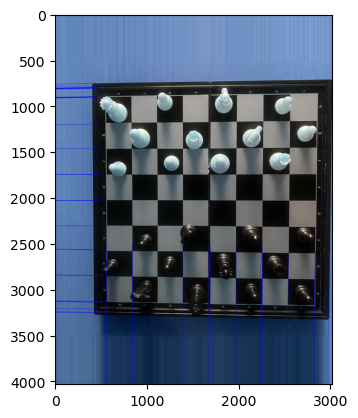

Dominant angle: 34.00 degrees
Rotation needed: -34.00 degrees


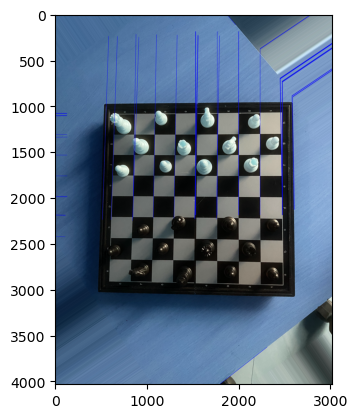

Dominant angle: 20.00 degrees
Rotation needed: -20.00 degrees


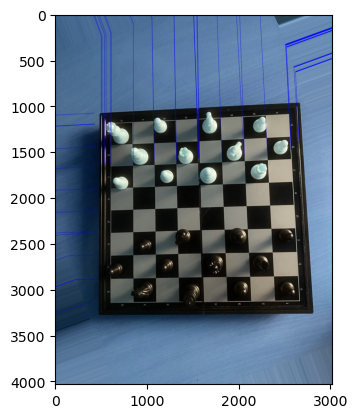

Dominant angle: 141.00 degrees
Rotation needed: 39.00 degrees


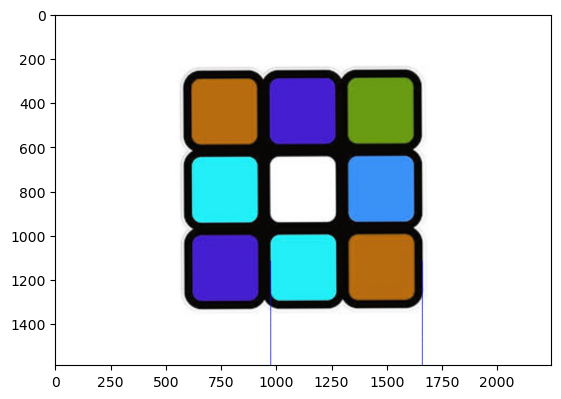

In [10]:
images = ["q2_data/2a.jpg", "q2_data/2b.jpg", "q2_data/2c.jpg", "q2_data/cube.png"]
for image in images:
    name = os.path.splitext(os.path.basename(image))[0]  # <-- this was missing
    
    angles_count = find_lines(image)
    top_3_angles = sorted(angles_count, key=angles_count.get, reverse=True)[:3]
    img = cv2.imread(f'linesDetected{name}.jpg')

    angle = np.degrees(top_3_angles[0])
    print(f"Dominant angle: {angle:.2f} degrees")
    
    if angle < 45:
        rotation_angle = -angle
    elif angle < 135:
        rotation_angle = 90 - angle
    else:
        rotation_angle = 180 - angle
    
    print(f"Rotation needed: {rotation_angle:.2f} degrees")
    
    rot_img = rotate_image(img, angle)
    
    plt.imsave(f'rotated_image_{name}.jpg', rot_img)  # <-- use name, not hardcoded
    plt.imshow(rot_img, cmap='gray')
    plt.show()

### Question 3 Image compression

In [11]:
## Sample images  in Data directory
def compress_image_fft(image_path, compress_ratio):
    # Load image using imread
    img = cv2.imread(image_path)
    # Convert image to grayscale
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    # Use numpy to get the fast fourier transform of the grayscale image
    f = np.fft.fft2(gray)
    f_shift = np.fft.fftshift(f)

    magnitude = np.abs(fshift)
    # Sort the absolute value of  the frequencies. You will have to flatten the frequencies => fSorted
    sorted_indices = np.argsort(magnitude.flatten())
    
    # Determine the threshold to keep using thresh = fSorted[int(np.floor((1-compress_ration)*len(fSorted)))]
    n_pixels = magnitude.size
    cutoff_index = int((1 - keep_fraction) * n_pixels)
    threshold_val = magnitude.flatten()[sorted_indices[cutoff_index]]
    # create a mask to help filter. mask = np.abs(computed_fourier) >  thresh
    mask = np.zeros_like(magnitude)
    mask[magnitude >= threshold_val] = 1
    # filter the Fourier using the mask filtered = computer_fourier * mask
    fshift_filtered = fshift * mask
    # apply inverse fourier to get a compressed version of the image
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.abs(np.fft.ifft2(f_ishift))
    # return the image obtained.
    return gray, img_back, mask

Processing q3a...


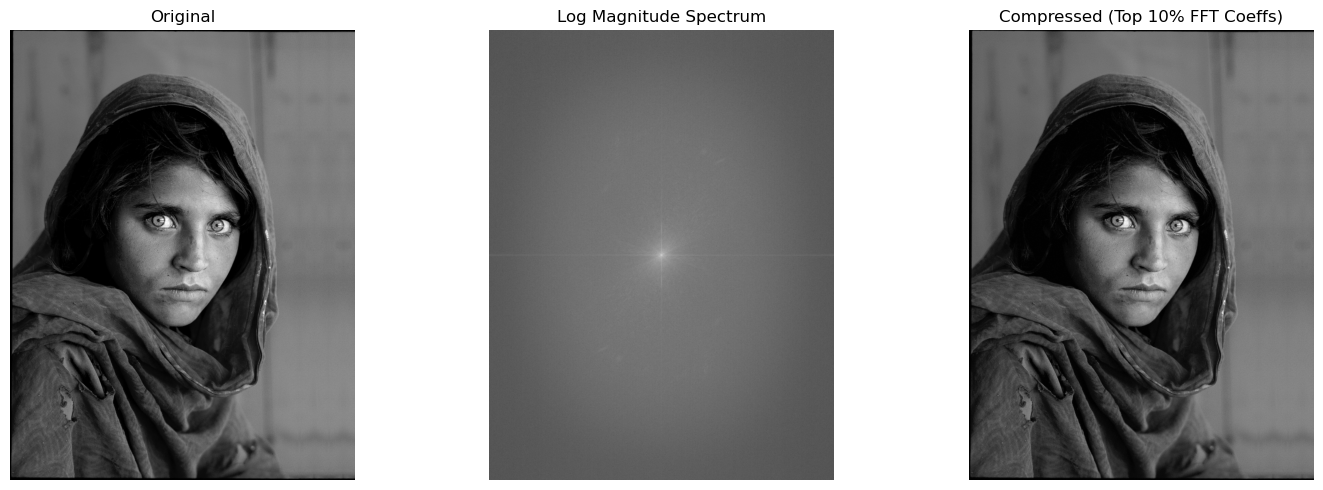

Processing q3b...


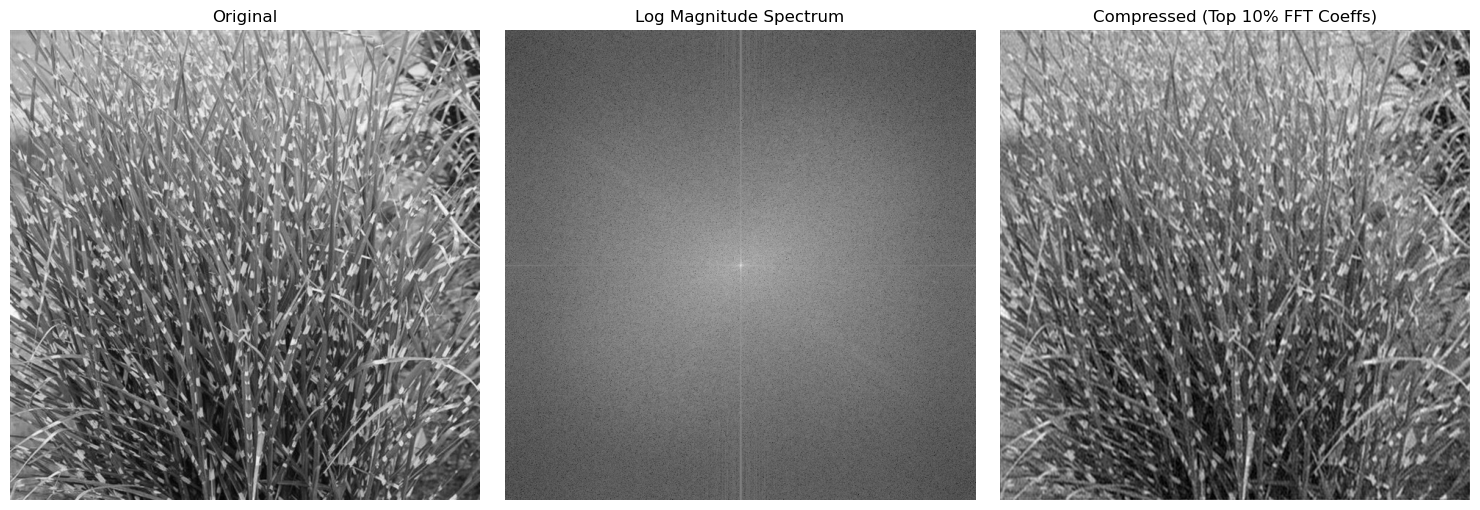

Processing sat_img1...


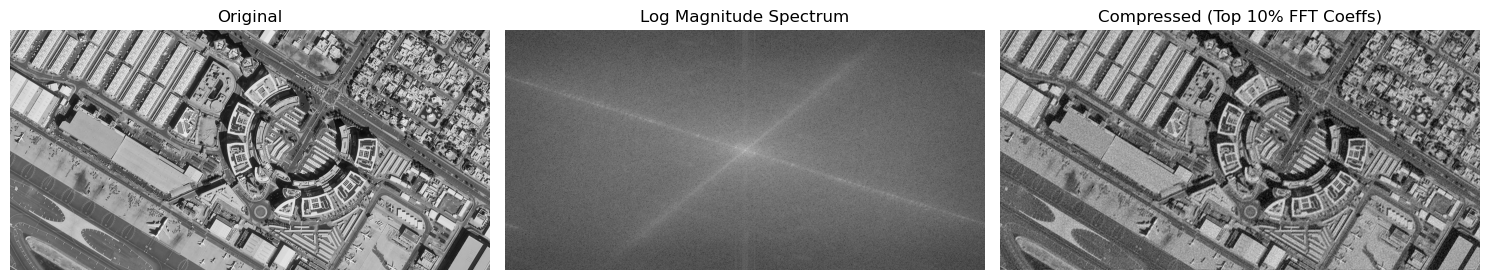

Q3 Processing Complete.


In [12]:
# --- 1. DEFINE THE FUNCTION WITH A NEW NAME ---
def compress_image_fft_new(image_path, keep_fraction=0.1):
    img = cv2.imread(image_path)
    if img is None:
        print(f"Error: Could not read {image_path}")
        return None, None, None
    
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    
    # FFT
    f = np.fft.fft2(gray)
    fshift = np.fft.fftshift(f)
    
    # Magnitude Spectrum
    magnitude = np.abs(fshift)
    
    # Thresholding
    sorted_indices = np.argsort(magnitude.flatten())
    n_pixels = magnitude.size
    cutoff_index = int((1 - keep_fraction) * n_pixels)
    threshold_val = magnitude.flatten()[sorted_indices[cutoff_index]]
    
    # Mask
    mask = np.zeros_like(magnitude)
    mask[magnitude >= threshold_val] = 1
    
    # Reconstruct
    fshift_filtered = fshift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    img_back = np.abs(np.fft.ifft2(f_ishift))
    
    return gray, img_back, mask

# --- 2. EXECUTE ---
data_dir = "q3_data"  
output_dir = "Assets"
os.makedirs(output_dir, exist_ok=True)

# List images
images = [f for f in os.listdir(data_dir) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]
if not images:
    print(f"No images found in {data_dir}. Check path.")

for filename in images:
    path = os.path.join(data_dir, filename)
    name = os.path.splitext(filename)[0]
    print(f"Processing {name}...")
    
    # CALL THE *NEW* FUNCTION
    original, compressed, mask = compress_image_fft_new(path, keep_fraction=0.1)
    
    if original is not None:
        cv2.imwrite(os.path.join(output_dir, f"compressed_{name}.jpg"), compressed)
        
        # Plot
        plt.figure(figsize=(15, 5))
        plt.subplot(131), plt.imshow(original, cmap='gray'), plt.title('Original'), plt.axis('off')
        plt.subplot(132), plt.imshow(np.log(1 + np.abs(np.fft.fftshift(np.fft.fft2(original)))), cmap='gray'), plt.title('Log Magnitude Spectrum'), plt.axis('off')
        plt.subplot(133), plt.imshow(compressed, cmap='gray'), plt.title(f'Compressed (Top 10% FFT Coeffs)'), plt.axis('off')
        plt.tight_layout()
        plt.show() # Show in notebook
        plt.savefig(os.path.join(output_dir, f"comparison_{name}.png"))
        plt.close()

print("Q3 Processing Complete.")

### Question 4 Data Augmentation

In [13]:
def data_augmentation(img, type):
    image = img # Fix variable name mismatch if user uses 'image' internally
    rows, cols = image.shape[:2] # Needed for rotation/shear
    
    if type=="resize1":
        # resize the  image to 224 x 224 use nearest neighbor 
        return cv2.resize(image, (224, 224), interpolation=cv2.INTER_NEAREST)
    elif type=="resize2":
        # resize the  image to 224 x 224 use cubic spline interpolation
        return cv2.resize(image, (224, 224), interpolation=cv2.INTER_CUBIC)
    elif type=="vertical_flip":
        # flip the image vertically
        return cv2.flip(image, 0)
    elif type=="horizontal_flip":
        # flip the image horizontally
        return cv2.flip(image, 1)
    elif type=="blur_noise":
        # add Gaussian noise
        return cv2.GaussianBlur(image, (15, 15), 0)
    elif type=="rotation":
        # # 90 degree rotation
        # return cv2.rotate(image, cv2.ROTATE_90_CLOCKWISE)
        # 30 degree rotation
        # FIXED: cv2.ROTATE_30_CLOCKWISE does not exist. Using warpAffine.
        M = cv2.getRotationMatrix2D((cols/2, rows/2), 30, 1)
        return cv2.warpAffine(image, M, (cols, rows))
    elif type=="shear on y-axis":
        # use your own parameters
        M = np.float32([[1, 0, 0], [0.5, 1, 0]])
        return cv2.warpAffine(image, M, (cols, int(rows*1.5)))
    elif type=="shear on x-axis":
        # use your own parameters
        M = np.float32([[1, 0.5, 0], [0, 1, 0]])
        return cv2.warpAffine(image, M, (int(cols*1.5), rows))
    return image
# --- Execution ---
# Use absolute paths to avoid issues
base_dir = r"c:\Users\Administrator\OneDrive - andrew.cmu.edu\Desktop\Spring26\CV\assignments\hw2\ACV Assignment 2"
data_dir = os.path.join(base_dir, "q2_data") # Using q2_data/2a.jpg
output_dir = os.path.join(base_dir, "Assets")
os.makedirs(output_dir, exist_ok=True)
image_path = os.path.join(data_dir, "2a.jpg")
img = cv2.imread(image_path)
if img is None:
    print(f"Error: Could not read {image_path}. Trying absolute path check.")
    # Check if file exists
    if not os.path.exists(image_path):
        print(f"File NOT found at {image_path}")
    else:
         print(f"File found but imread failed.")
    exit()
print(f"Processing {image_path}...")
# Dictionary of augmentations to run
augmentations = [
    'resize1', 'resize2', 
    'vertical_flip', 'horizontal_flip', 
    'blur_noise', 
    'rotation', 
    'shear_x', 'shear_y'
]
# Process and Save
for aug_type in augmentations:
    augmented = data_augmentation(img, aug_type)
    
    if augmented is not None:
        output_filename = f"q4_{aug_type}.jpg"
        output_path = os.path.join(output_dir, output_filename)
        cv2.imwrite(os.path.join(output_dir, output_filename), augmented)
        print(f"Saved {output_filename}")
        
        # Save comparison plot for report (Optional but good for checking)
        # We might just use the individual images in LaTeX
        


Processing c:\Users\Administrator\OneDrive - andrew.cmu.edu\Desktop\Spring26\CV\assignments\hw2\ACV Assignment 2\q2_data\2a.jpg...
Saved q4_resize1.jpg
Saved q4_resize2.jpg
Saved q4_vertical_flip.jpg
Saved q4_horizontal_flip.jpg
Saved q4_blur_noise.jpg
Saved q4_rotation.jpg
Saved q4_shear_x.jpg
Saved q4_shear_y.jpg
